In [ ]:
from pathlib import Path
import os
import zipfile
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    cohen_kappa_score,
    confusion_matrix,
    classification_report
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from tqdm.auto import tqdm

In [ ]:
SEED = 123

def seed_everything(seed=123):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True

print("DEVICE:", DEVICE)

DEVICE: cuda


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
PROJECT_DIR = Path("/content/drive/MyDrive/Knee_OA_Project")
ZIP_PATH = PROJECT_DIR / "archive (10).zip"
DATA_DIR = Path("/content/kneeoa_data")

if not DATA_DIR.exists():
    print("Extracting dataset...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(DATA_DIR)
    print("Done.")
else:
    print("Dataset already extracted.")

EXPERIMENT_NAME = "resnet50_fullimg256_wce_v2"
RUN_DIR = PROJECT_DIR / "experiments" / EXPERIMENT_NAME
RUN_DIR.mkdir(parents=True, exist_ok=True)

CKPT_PATH = RUN_DIR / "best_model.pt"
HISTORY_PATH = RUN_DIR / "history.csv"
TEST_PREDS_PATH = RUN_DIR / "test_predictions.csv"
CM_PATH = RUN_DIR / "test_confusion_matrix.png"
SUMMARY_PATH = RUN_DIR / "summary.txt"

print("RUN_DIR:", RUN_DIR)

Extracting dataset...
Done.
RUN_DIR: /content/drive/MyDrive/Knee_OA_Project/experiments/resnet50_fullimg256_wce_v2


In [ ]:
CLASS_NAMES = ["0", "1", "2", "3", "4"]
LABEL_MAP = {c: int(c) for c in CLASS_NAMES}
SPLITS = ["train", "val", "test"]
VALID_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

rows = []
for split in SPLITS:
    split_dir = DATA_DIR / split
    if not split_dir.exists():
        print(f"Missing split folder: {split_dir}")
        continue

    for cls in CLASS_NAMES:
        cls_dir = split_dir / cls
        if not cls_dir.exists():
            print(f"Missing class folder: {cls_dir}")
            continue

        for p in cls_dir.rglob("*"):
            if p.is_file() and p.suffix.lower() in VALID_EXTS:
                rows.append({
                    "path": str(p),
                    "label": LABEL_MAP[cls],
                    "split": split
                })

df = pd.DataFrame(rows)

print("Total images found:", len(df))
print(df.groupby(["split", "label"]).size().unstack(fill_value=0))

train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df   = df[df["split"] == "val"].reset_index(drop=True)
test_df  = df[df["split"] == "test"].reset_index(drop=True)

print(len(train_df), len(val_df), len(test_df))

Total images found: 8260
label     0     1     2    3    4
split                            
test    639   296   447  223   51
train  2286  1046  1516  757  173
val     328   153   212  106   27
5778 826 1656


In [ ]:
IMG_SIZE = 256
BATCH_SIZE = 32
NUM_WORKERS = 0

EPOCHS = 18
PATIENCE = 4

LR = 1.5e-4
WEIGHT_DECAY = 1e-4

print({
    "IMG_SIZE": IMG_SIZE,
    "BATCH_SIZE": BATCH_SIZE,
    "EPOCHS": EPOCHS,
    "PATIENCE": PATIENCE,
    "LR": LR,
    "WEIGHT_DECAY": WEIGHT_DECAY,
    "NUM_WORKERS": NUM_WORKERS
})

{'IMG_SIZE': 256, 'BATCH_SIZE': 32, 'EPOCHS': 18, 'PATIENCE': 4, 'LR': 0.00015, 'WEIGHT_DECAY': 0.0001, 'NUM_WORKERS': 0}


In [ ]:
train_tfms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(5),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

eval_tfms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

In [ ]:
class KneeOADataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["path"])
        img = ImageOps.exif_transpose(img)
        y = int(row["label"])

        if self.transform is not None:
            img = self.transform(img)

        return img, y, row["path"]

In [ ]:
train_loader = DataLoader(
    KneeOADataset(train_df, train_tfms),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    KneeOADataset(val_df, eval_tfms),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    KneeOADataset(test_df, eval_tfms),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

xb, yb, pb = next(iter(train_loader))
print("Images:", xb.shape)
print("Labels:", yb.shape)
print("Example labels:", yb[:10].tolist())
print("Example path:", pb[0])

Images: torch.Size([32, 3, 256, 256])
Labels: torch.Size([32])
Example labels: [2, 0, 1, 0, 2, 4, 1, 0, 0, 2]
Example path: /content/kneeoa_data/train/2/9587941L.png


In [ ]:
label_counts = train_df["label"].value_counts().sort_index()
counts = label_counts.values.astype(np.float32)

class_weights = 1.0 / counts
class_weights = class_weights / class_weights.sum() * len(class_weights)
class_weights = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)

print("Train label counts:\n", label_counts)
print("Class weights:", class_weights)

Train label counts:
 label
0    2286
1    1046
2    1516
3     757
4     173
Name: count, dtype: int64
Class weights: tensor([0.2389, 0.5222, 0.3603, 0.7215, 3.1571], device='cuda:0')


In [ ]:
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model.fc.in_features, 5)
)
model = model.to(DEVICE)

print("Model ready.")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 204MB/s]


Model ready.


In [ ]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))

In [ ]:
def plus_minus_one_accuracy(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return float(np.mean(np.abs(y_true - y_pred) <= 1))

def compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "qwk": cohen_kappa_score(y_true, y_pred, weights="quadratic"),
        "pm1_accuracy": plus_minus_one_accuracy(y_true, y_pred)
    }

In [ ]:
def run_one_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    losses = []
    y_true_all = []
    y_pred_all = []

    pbar = tqdm(loader, leave=False)

    for images, labels, _ in pbar:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
            logits = model(images)
            loss = criterion(logits, labels)

        if is_train:
            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

        preds = torch.argmax(logits, dim=1)

        losses.append(loss.item())
        y_true_all.extend(labels.detach().cpu().numpy().tolist())
        y_pred_all.extend(preds.detach().cpu().numpy().tolist())

        pbar.set_postfix(loss=f"{np.mean(losses):.4f}")

    metrics = compute_metrics(y_true_all, y_pred_all)
    metrics["loss"] = float(np.mean(losses))
    return metrics

In [ ]:
history = []
best_f1 = -1.0
best_epoch = -1
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    print(f"\n===== Epoch {epoch}/{EPOCHS} =====")

    train_metrics = run_one_epoch(model, train_loader, optimizer=optimizer)
    val_metrics = run_one_epoch(model, val_loader, optimizer=None)

    scheduler.step(val_metrics["f1_macro"])

    row = {
        "epoch": epoch,
        **{f"train_{k}": v for k, v in train_metrics.items()},
        **{f"val_{k}": v for k, v in val_metrics.items()},
        "lr": float(optimizer.param_groups[0]["lr"])
    }
    history.append(row)

    print("Train:", train_metrics)
    print("Val  :", val_metrics)

    current_f1 = val_metrics["f1_macro"]

    if current_f1 > best_f1:
        best_f1 = current_f1
        best_epoch = epoch
        patience_counter = 0

        torch.save({
            "epoch": int(epoch),
            "model_state_dict": model.state_dict(),
            "val_metrics": {k: float(v) for k, v in val_metrics.items()},
            "config": {
                "IMG_SIZE": IMG_SIZE,
                "BATCH_SIZE": BATCH_SIZE,
                "LR": LR,
                "WEIGHT_DECAY": WEIGHT_DECAY
            }
        }, CKPT_PATH)

        print(f"Saved best checkpoint to: {CKPT_PATH}")
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{PATIENCE}")

    pd.DataFrame(history).to_csv(HISTORY_PATH, index=False)

    if patience_counter >= PATIENCE:
        print("Early stopping triggered.")
        break

print(f"\nBest epoch: {best_epoch}")
print(f"Best val macro F1: {best_f1:.4f}")


===== Epoch 1/18 =====


  0%|          | 0/181 [00:00<?, ?it/s]

  0%|          | 0/26 [00:00<?, ?it/s]

Train: {'accuracy': 0.843717549325026, 'precision_macro': 0.8674593410146951, 'recall_macro': 0.8790035836491329, 'f1_macro': 0.8709914027528217, 'balanced_accuracy': np.float64(0.8790035836491329), 'qwk': np.float64(0.9181396266251481), 'pm1_accuracy': 0.9773277950848044, 'loss': 0.31793261372911336}
Val  : {'accuracy': 0.6295399515738499, 'precision_macro': 0.6554717704438542, 'recall_macro': 0.6644049520406413, 'f1_macro': 0.6591363439200487, 'balanced_accuracy': np.float64(0.6644049520406413), 'qwk': np.float64(0.790825461505217), 'pm1_accuracy': 0.9322033898305084, 'loss': 1.0652878685639455}
Saved best checkpoint to: /content/drive/MyDrive/Knee_OA_Project/experiments/resnet50_fullimg256_wce_v2/best_model.pt

===== Epoch 2/18 =====


  0%|          | 0/181 [00:00<?, ?it/s]

...

  0%|          | 0/26 [00:00<?, ?it/s]

Train: {'accuracy': 0.9430598823122187, 'precision_macro': 0.9529003423065845, 'recall_macro': 0.955140829682404, 'f1_macro': 0.9540033408540669, 'balanced_accuracy': np.float64(0.955140829682404), 'qwk': np.float64(0.9579572812854061), 'pm1_accuracy': 0.9799238490827276, 'loss': 0.12887078312673292}
Val  : {'accuracy': 0.6452784503631961, 'precision_macro': 0.6648056941178172, 'recall_macro': 0.6538400322035036, 'f1_macro': 0.658061226479815, 'balanced_accuracy': np.float64(0.6538400322035036), 'qwk': np.float64(0.7860356196462686), 'pm1_accuracy': 0.9261501210653753, 'loss': 1.3325149760796473}
No improvement. Patience: 3/4

===== Epoch 7/18 =====


  0%|          | 0/181 [00:00<?, ?it/s]

  0%|          | 0/26 [00:00<?, ?it/s]

Train: {'accuracy': 0.9560401523018346, 'precision_macro': 0.9612391569816843, 'recall_macro': 0.967100445119795, 'f1_macro': 0.9640356123617352, 'balanced_accuracy': np.float64(0.967100445119795), 'qwk': np.float64(0.9719618778196317), 'pm1_accuracy': 0.9887504326756663, 'loss': 0.10059031510715327}
Val  : {'accuracy': 0.639225181598063, 'precision_macro': 0.6581219632830002, 'recall_macro': 0.6494566912002824, 'f1_macro': 0.6528407709805599, 'balanced_accuracy': np.float64(0.6494566912002824), 'qwk': np.float64(0.7796558270561578), 'pm1_accuracy': 0.9188861985472155, 'loss': 1.3766073538706853}
No improvement. Patience: 4/4
Early stopping triggered.

Best epoch: 3
Best val macro F1: 0.6701


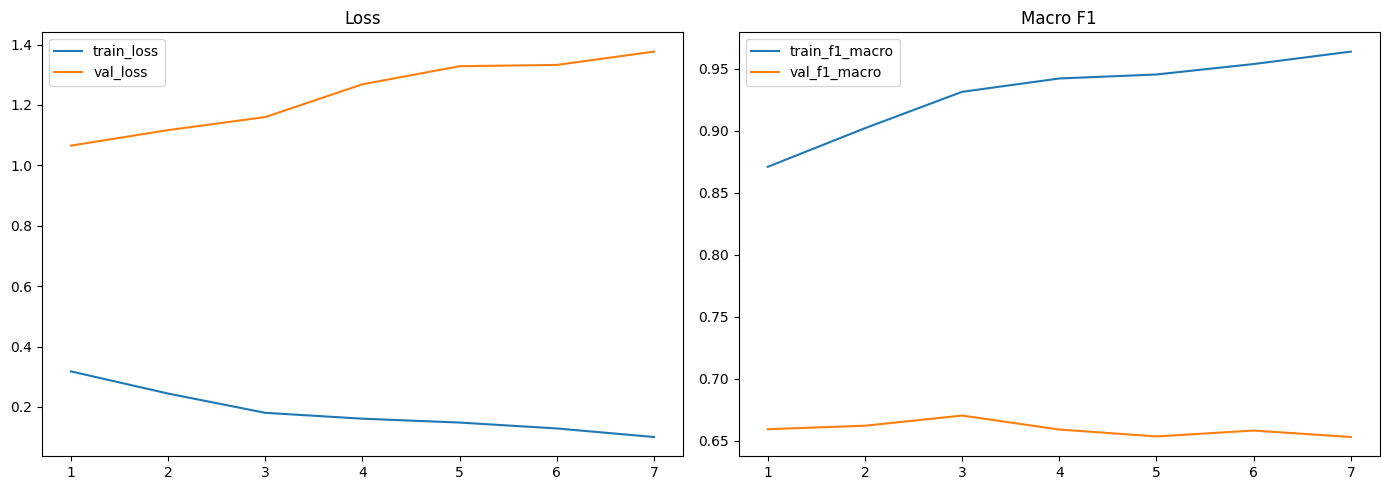

In [ ]:
hist_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hist_df["epoch"], hist_df["train_loss"], label="train_loss")
axes[0].plot(hist_df["epoch"], hist_df["val_loss"], label="val_loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(hist_df["epoch"], hist_df["train_f1_macro"], label="train_f1_macro")
axes[1].plot(hist_df["epoch"], hist_df["val_f1_macro"], label="val_f1_macro")
axes[1].set_title("Macro F1")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

print("Loaded best checkpoint from epoch:", ckpt["epoch"])
print("Best val metrics:", ckpt["val_metrics"])

Loaded best checkpoint from epoch: 3
Best val metrics: {'accuracy': 0.6598062953995157, 'precision_macro': 0.6690312877026018, 'recall_macro': 0.6739658434320192, 'f1_macro': 0.6701443731145263, 'balanced_accuracy': 0.6739658434320192, 'qwk': 0.7957604921727478, 'pm1_accuracy': 0.9261501210653753, 'loss': 1.159865459570518}


In [ ]:
@torch.no_grad()
def predict_loader(model, loader):
    model.eval()

    y_true_all = []
    y_pred_all = []
    all_paths = []

    for images, labels, paths in tqdm(loader):
        images = images.to(DEVICE, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
            logits = model(images)

        preds = torch.argmax(logits, dim=1)

        y_true_all.extend(labels.numpy().tolist())
        y_pred_all.extend(preds.cpu().numpy().tolist())
        all_paths.extend(paths)

    return y_true_all, y_pred_all, all_paths

In [ ]:
val_true, val_pred, _ = predict_loader(model, val_loader)
val_metrics = compute_metrics(val_true, val_pred)

print("Validation metrics:")
for k, v in val_metrics.items():
    print(f"{k}: {v:.4f}")

  0%|          | 0/26 [00:00<?, ?it/s]

Validation metrics:
accuracy: 0.6598
precision_macro: 0.6690
recall_macro: 0.6740
f1_macro: 0.6701
balanced_accuracy: 0.6740
qwk: 0.7958
pm1_accuracy: 0.9262


In [ ]:
test_true, test_pred, test_paths = predict_loader(model, test_loader)
test_metrics = compute_metrics(test_true, test_pred)

print("Test metrics:")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")

  0%|          | 0/52 [00:00<?, ?it/s]

Test metrics:
accuracy: 0.6751
precision_macro: 0.6730
recall_macro: 0.6850
f1_macro: 0.6782
balanced_accuracy: 0.6850
qwk: 0.8262
pm1_accuracy: 0.9457


In [ ]:
print(classification_report(test_true, test_pred, digits=4))

              precision    recall  f1-score   support

           0     0.7489    0.7887    0.7683       639
           1     0.3346    0.2905    0.3110       296
           2     0.6755    0.6846    0.6800       447
           3     0.8203    0.7982    0.8091       223
           4     0.7857    0.8627    0.8224        51

    accuracy                         0.6751      1656
   macro avg     0.6730    0.6850    0.6782      1656
weighted avg     0.6658    0.6751    0.6699      1656



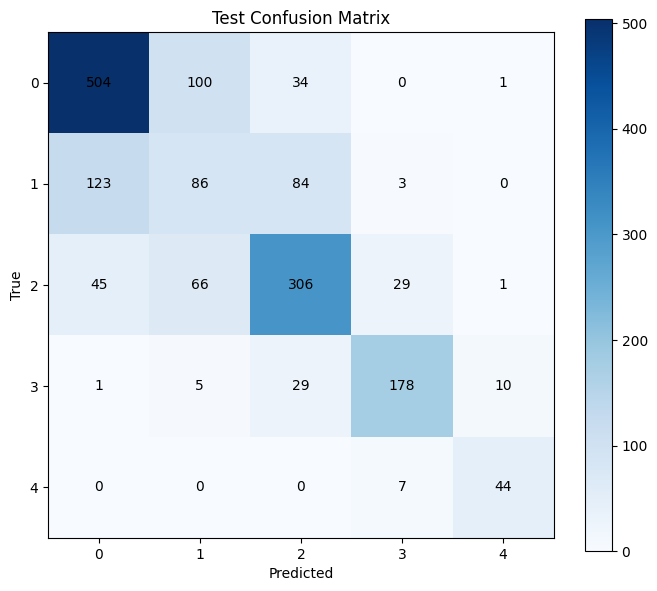

Saved confusion matrix to: /content/drive/MyDrive/Knee_OA_Project/experiments/resnet50_fullimg256_wce_v2/test_confusion_matrix.png


In [ ]:
cm = confusion_matrix(test_true, test_pred)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(CLASS_NAMES)
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Test Confusion Matrix")

for i in range(5):
    for j in range(5):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar(im)
plt.tight_layout()
plt.savefig(CM_PATH, dpi=200, bbox_inches="tight")
plt.show()

print("Saved confusion matrix to:", CM_PATH)

In [ ]:
pred_df = pd.DataFrame({
    "path": test_paths,
    "y_true": test_true,
    "y_pred": test_pred
})
pred_df["abs_error"] = (pred_df["y_true"] - pred_df["y_pred"]).abs()

pred_df.to_csv(TEST_PREDS_PATH, index=False)
print("Saved:", TEST_PREDS_PATH)
pred_df.head()

Saved: /content/drive/MyDrive/Knee_OA_Project/experiments/resnet50_fullimg256_wce_v2/test_predictions.csv


,path,y_true,y_pred,abs_error
0,/content/kneeoa_data/test/0/9827858L.png,0,0,0
1,/content/kneeoa_data/test/0/9030418R.png,0,0,0
2,/content/kneeoa_data/test/0/9594682R.png,0,0,0
3,/content/kneeoa_data/test/0/9733523L.png,0,0,0
4,/content/kneeoa_data/test/0/9789177L.png,0,0,0


In [ ]:
summary_lines = []
summary_lines.append(f"Experiment: {EXPERIMENT_NAME}")
summary_lines.append(f"Best epoch: {ckpt['epoch']}")
summary_lines.append("")

summary_lines.append("Validation metrics:")
for k, v in val_metrics.items():
    summary_lines.append(f"{k}: {v:.4f}")

summary_lines.append("")
summary_lines.append("Test metrics:")
for k, v in test_metrics.items():
    summary_lines.append(f"{k}: {v:.4f}")

summary_text = "\n".join(summary_lines)

with open(SUMMARY_PATH, "w") as f:
    f.write(summary_text)

print(summary_text)
print("\nSaved summary to:", SUMMARY_PATH)

Experiment: resnet50_fullimg256_wce_v2
Best epoch: 3

Validation metrics:
accuracy: 0.6598
precision_macro: 0.6690
recall_macro: 0.6740
f1_macro: 0.6701
balanced_accuracy: 0.6740
qwk: 0.7958
pm1_accuracy: 0.9262

Test metrics:
accuracy: 0.6751
precision_macro: 0.6730
recall_macro: 0.6850
f1_macro: 0.6782
balanced_accuracy: 0.6850
qwk: 0.8262
pm1_accuracy: 0.9457

Saved summary to: /content/drive/MyDrive/Knee_OA_Project/experiments/resnet50_fullimg256_wce_v2/summary.txt
